In [9]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
from app.model_utils import StockGRU, StockLSTM
from app.preproccesing import fetch_stock_data, prepare_datasets

In [70]:
def train_model(model, train_loader, val_loader, target_scaler, ticker, epochs=50, lr=0.001):
    import os
    import torch
    from sklearn.metrics import mean_absolute_error, r2_score
    from torch import nn

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    criterion = nn.HuberLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_r2 = -float('inf')
    history = {
        'train_loss': [],
        'train_mae': [],
        'train_r2': [],
        'val_loss': [],
        'val_mae': [],
        'val_r2': []
    }

    for epoch in range(epochs):
        # Training Phase
        model.train()
        train_loss = 0
        train_preds, train_true = [], []

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch.unsqueeze(1))
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_preds.append(outputs.detach().cpu())
            train_true.append(y_batch.unsqueeze(1).detach().cpu())

        # Training metrics
        train_preds = torch.cat(train_preds).numpy()
        train_true = torch.cat(train_true).numpy()

        train_preds_raw = target_scaler.inverse_transform(train_preds.reshape(-1, 1)).flatten()
        train_true_raw = target_scaler.inverse_transform(train_true.reshape(-1, 1)).flatten()

        train_mae = mean_absolute_error(train_true_raw, train_preds_raw)
        train_r2 = r2_score(train_true_raw, train_preds_raw)

        # Validation Phase
        model.eval()
        val_loss = 0
        val_preds, val_true = [], []

        with torch.no_grad():
            for X_val, y_val in val_loader:
                X_val, y_val = X_val.to(device), y_val.to(device)
                outputs = model(X_val)
                val_loss += criterion(outputs, y_val.unsqueeze(1)).item()

                val_preds.append(outputs.cpu())
                val_true.append(y_val.cpu())

        # Validation metrics
        val_preds = torch.cat(val_preds).numpy()
        val_true = torch.cat(val_true).numpy()

        val_preds_raw = target_scaler.inverse_transform(val_preds.reshape(-1, 1)).flatten()
        val_true_raw = target_scaler.inverse_transform(val_true.reshape(-1, 1)).flatten()

        val_mae = mean_absolute_error(val_true_raw, val_preds_raw)
        val_r2 = r2_score(val_true_raw, val_preds_raw)

        history['train_loss'].append(train_loss / len(train_loader))
        history['train_mae'].append(train_mae)
        history['train_r2'].append(train_r2)
        history['val_loss'].append(val_loss / len(val_loader))
        history['val_mae'].append(val_mae)
        history['val_r2'].append(val_r2)

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"[Train] Loss: {history['train_loss'][-1]:.4f} | MAE: ${train_mae:.2f} | R²: {train_r2:.4f}")
        print(f"[Val]   Loss: {history['val_loss'][-1]:.4f} | MAE: ${val_mae:.2f} | R²: {val_r2:.4f}")

        # Save best model (ticker-based)
        model_dir = os.path.join('..', 'app', 'models', ticker)
        os.makedirs(model_dir, exist_ok=True)
        model_save_path = os.path.join(model_dir, f'best_{model.__class__.__name__}.pth')

        if val_r2 > best_r2:
            best_r2 = val_r2
            torch.save(model.state_dict(), model_save_path)
            print(f"New best model saved for {ticker} (R²: {best_r2:.4f})")

    return model, history


In [12]:
def plot_training_history(history, model_name):
    plt.figure(figsize=(14, 5))

    # Plot 1 - Loss
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Training Loss', color='blue', linestyle='-', linewidth=2)
    plt.plot(history['val_loss'], label='Validation Loss', color='red', linestyle='-', linewidth=2)
    plt.title(f'Training vs Validation Loss {model_name}', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss (Huber)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)

    # Plot 2 - R² Score
    plt.subplot(1, 2, 2)
    plt.plot(history['train_r2'], label='Training R²', color='blue', linestyle='--', linewidth=2)
    plt.plot(history['val_r2'], label='Validation R²', color='red', linestyle='--', linewidth=2)
    plt.title('Training vs Validation R² Score', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('R² Score', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt

def compare_models(history1, history2, title="Model Comparison"):
    metrics = ['loss', 'mae', 'r2']
    for metric in metrics:
        plt.figure(figsize=(8, 4))
        plt.plot(history1[f'train_{metric}'], label='Train - Model 1')
        plt.plot(history1[f'val_{metric}'], label='Val - Model 1')
        plt.plot(history2[f'train_{metric}'], label='Train - Model 2')
        plt.plot(history2[f'val_{metric}'], label='Val - Model 2')
        plt.title(f"{title} - {metric.upper()}")
        plt.xlabel("Epochs")
        plt.ylabel(metric.upper())
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


In [14]:
def plot_predictions(true_values, pred_values, model_name, tickers):
    plt.figure(figsize=(14, 5))
    plt.plot(true_values, label='True Prices', color='blue', linewidth=2)
    plt.plot(pred_values, label='Predicted Prices', color='red', linestyle='--', linewidth=2)
    plt.title(f'{model_name} Predictions vs True Prices', fontsize=14)
    plt.xlabel('Time', fontsize=12)
    plt.ylabel('Stock Price ($)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()

[*********************100%***********************]  1 of 1 completed

Using device: cpu

 Fetching and training models for TSLA
Fetching data for TSLA...
Preparing datasets for TSLA...
Training LSTM model for TSLA
Epoch 1/50
[Train] Loss: 0.1706 | MAE: $49.06 | R²: 0.3891
[Val]   Loss: 0.0225 | MAE: $18.48 | R²: 0.6094
New best model saved for TSLA (R²: 0.6094)


Epoch 2/50
[Train] Loss: 0.0334 | MAE: $21.24 | R²: 0.8834
[Val]   Loss: 0.0084 | MAE: $11.02 | R²: 0.8533
New best model saved for TSLA (R²: 0.8533)
Epoch 3/50
[Train] Loss: 0.0158 | MAE: $15.17 | R²: 0.9450
[Val]   Loss: 0.0093 | MAE: $11.39 | R²: 0.8363
Epoch 4/50
[Train] Loss: 0.0135 | MAE: $13.65 | R²: 0.9538
[Val]   Loss: 0.0080 | MAE: $10.48 | R²: 0.8609
New best model saved for TSLA (R²: 0.8609)
Epoch 5/50
[Train] Loss: 0.0125 | MAE: $12.99 | R²: 0.9570
[Val]   Loss: 0.0074 | MAE: $10.14 | R²: 0.8701
New best model saved for TSLA (R²: 0.8701)
Epoch 6/50
[Train] Loss: 0.0109 | MAE: $12.17 | R²: 0.9623
[Val]   Loss: 0.0067 | MAE: $9.67 | R²: 0.8826
New best model saved for TSLA (R²: 0.8826)
Epoch 7/50
[Train] Loss: 0.0104 | MAE: $11.82 | R²: 0.9639
[Val]   Loss: 0.0066 | MAE: $9.49 | R²: 0.8849
New best model saved for TSLA (R²: 0.8849)
Epoch 8/50
[Train] Loss: 0.0098 | MAE: $11.41 | R²: 0.9661
[Val]   Loss: 0.0064 | MAE: $9.33 | R²: 0.8877
New best model saved for TSLA (R²: 0.88

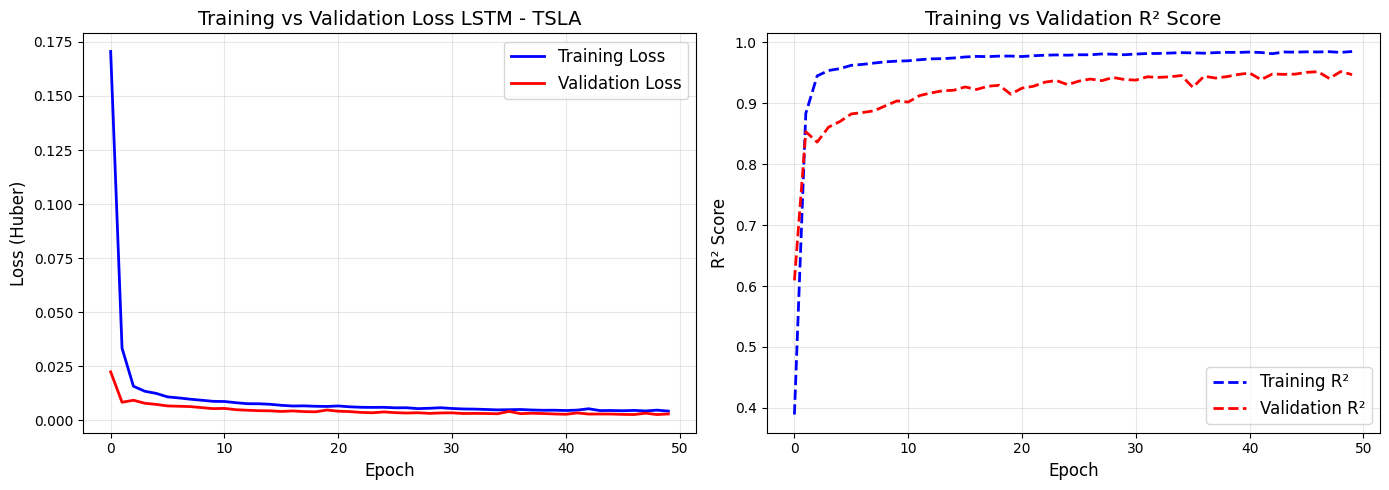

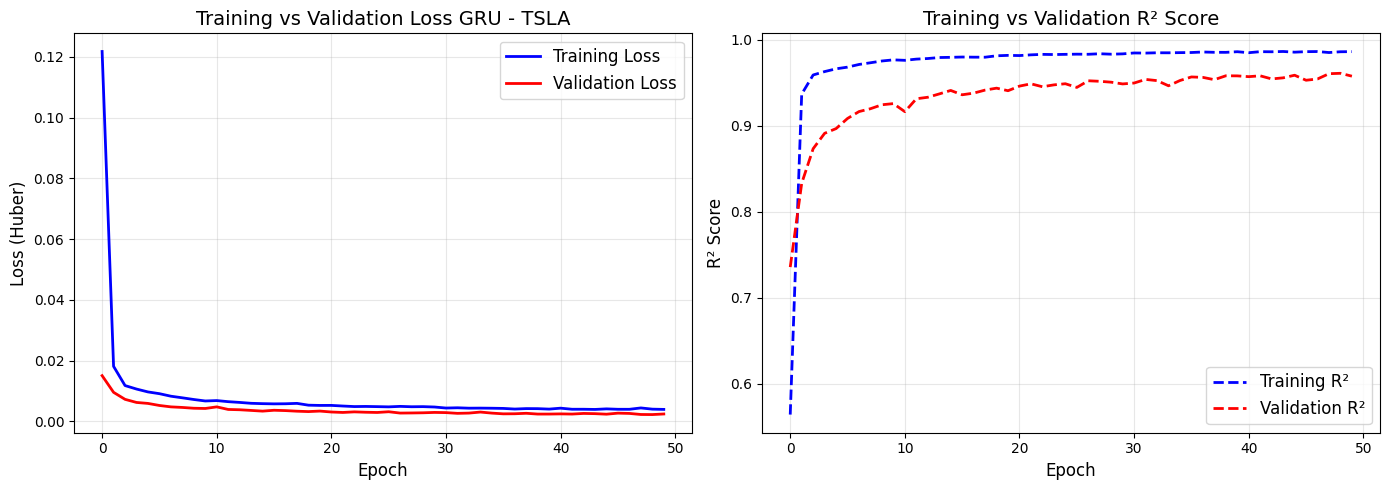

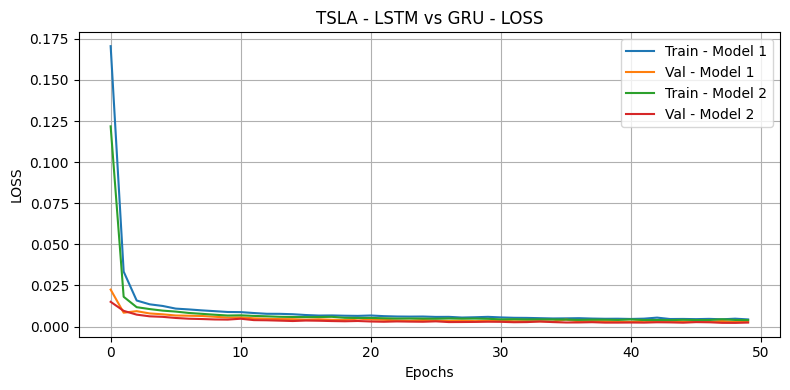

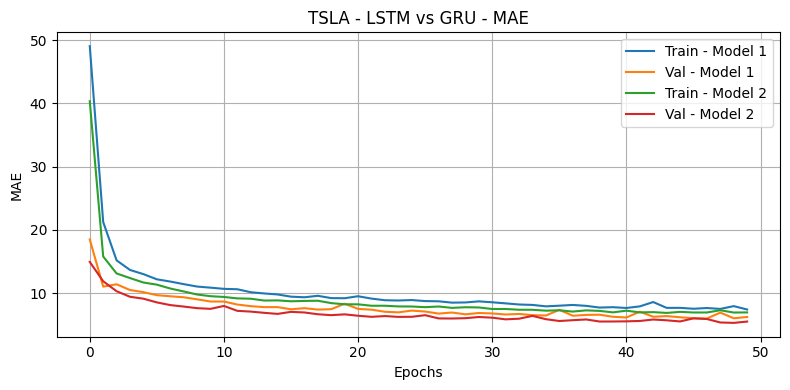

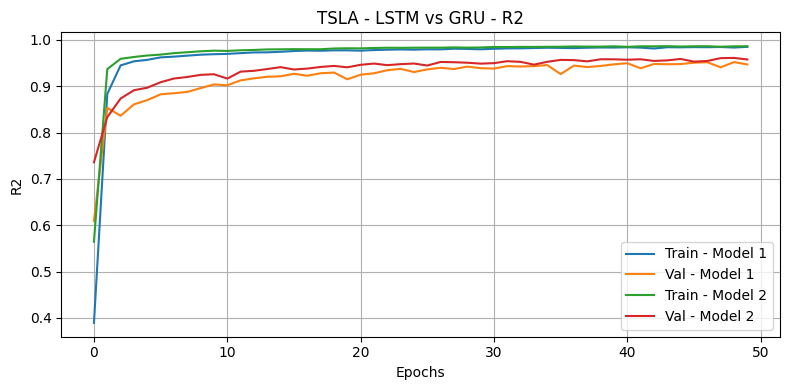

[*********************100%***********************]  1 of 1 completed


 Fetching and training models for AAPL
Fetching data for AAPL...
Preparing datasets for AAPL...
Training LSTM model for AAPL


Epoch 1/50
[Train] Loss: 0.2056 | MAE: $15.03 | R²: 0.3252
[Val]   Loss: 0.3879 | MAE: $25.31 | R²: -7.9790
New best model saved for AAPL (R²: -7.9790)
Epoch 2/50
[Train] Loss: 0.0424 | MAE: $6.67 | R²: 0.8774
[Val]   Loss: 0.0985 | MAE: $11.64 | R²: -1.2561
New best model saved for AAPL (R²: -1.2561)
Epoch 3/50
[Train] Loss: 0.0186 | MAE: $4.39 | R²: 0.9462
[Val]   Loss: 0.0537 | MAE: $8.24 | R²: -0.2258
New best model saved for AAPL (R²: -0.2258)
Epoch 4/50
[Train] Loss: 0.0144 | MAE: $3.87 | R²: 0.9590
[Val]   Loss: 0.0355 | MAE: $6.53 | R²: 0.1895
New best model saved for AAPL (R²: 0.1895)
Epoch 5/50
[Train] Loss: 0.0126 | MAE: $3.62 | R²: 0.9639
[Val]   Loss: 0.0338 | MAE: $6.41 | R²: 0.2267
New best model saved for AAPL (R²: 0.2267)
Epoch 6/50
[Train] Loss: 0.0114 | MAE: $3.44 | R²: 0.9671
[Val]   Loss: 0.0330 | MAE: $6.36 | R²: 0.2452
New best model saved for AAPL (R²: 0.2452)
Epoch 7/50
[Train] Loss: 0.0110 | MAE: $3.35 | R²: 0.9685
[Val]   Loss: 0.0245 | MAE: $5.41 | R²: 0.439

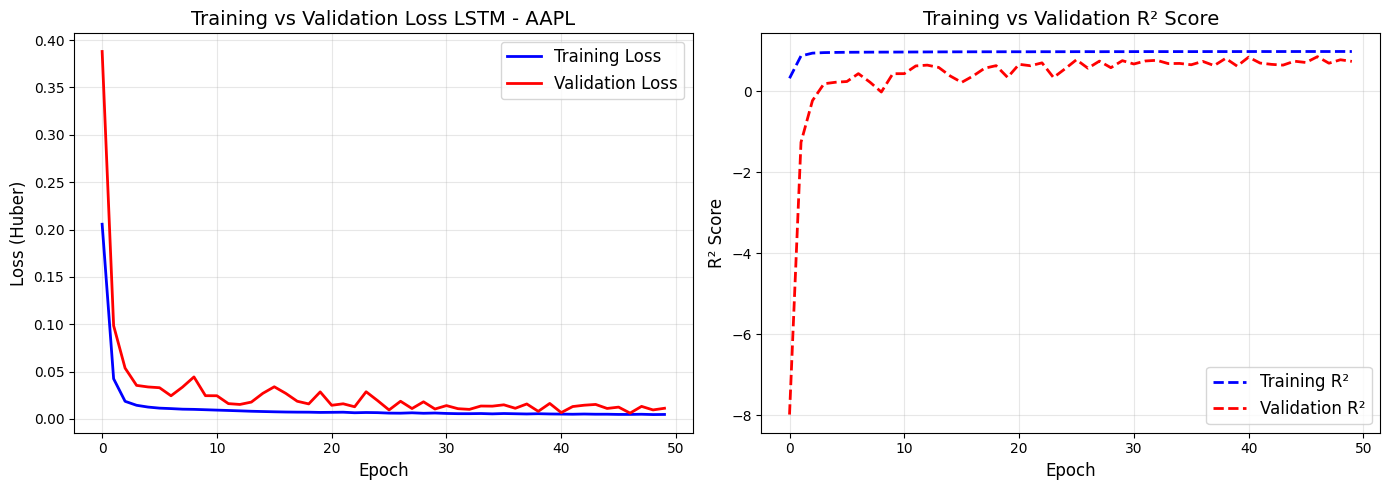

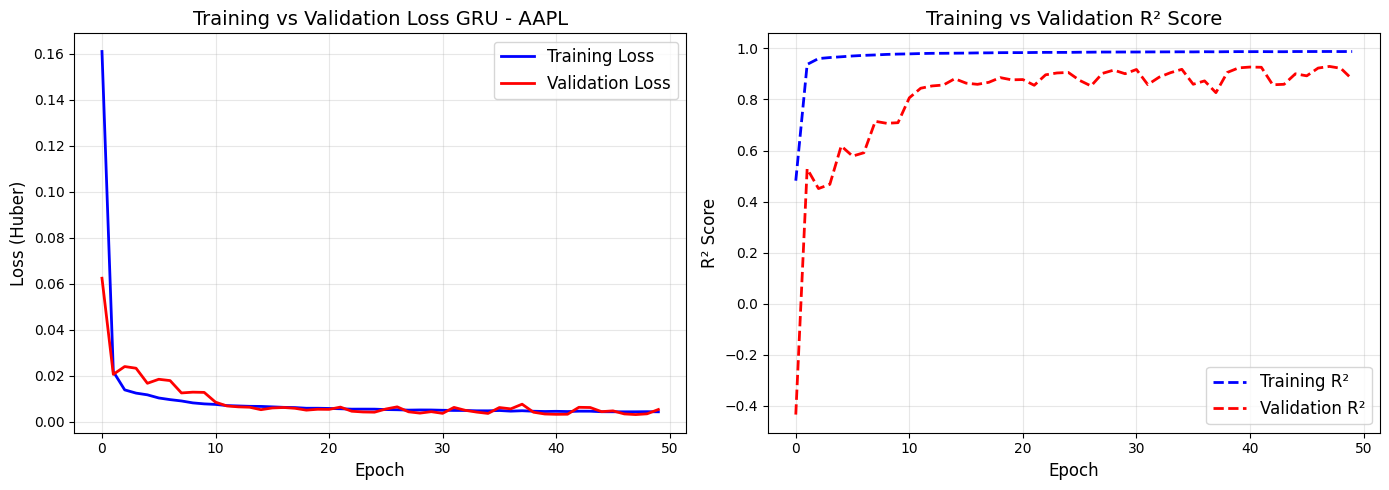

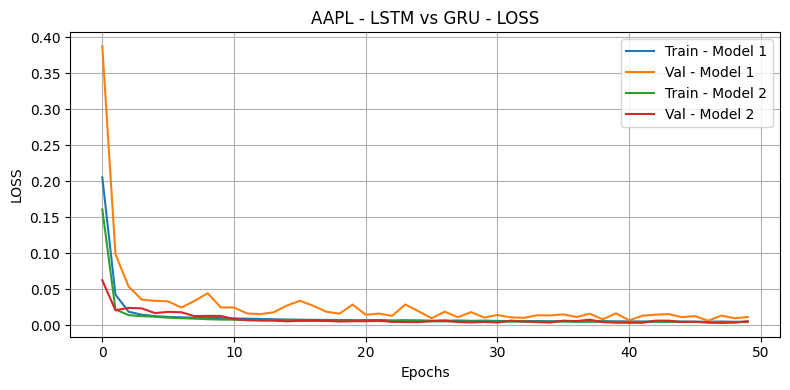

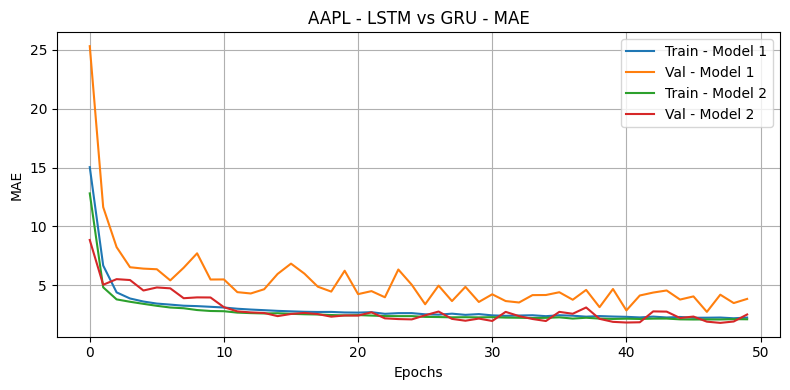

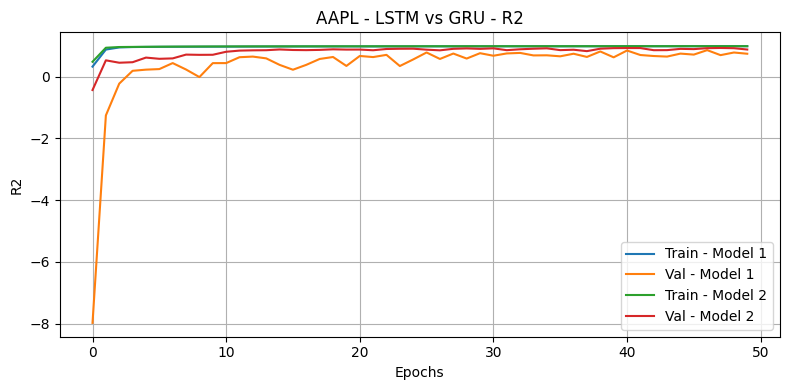

[*********************100%***********************]  1 of 1 completed


 Fetching and training models for AMZN
Fetching data for AMZN...
Preparing datasets for AMZN...
Training LSTM model for AMZN
Epoch 1/50
[Train] Loss: 0.1025 | MAE: $17.46 | R²: 0.4236
[Val]   Loss: 0.0293 | MAE: $10.06 | R²: 0.7345
New best model saved for AMZN (R²: 0.7345)


Epoch 2/50
[Train] Loss: 0.0135 | MAE: $5.95 | R²: 0.9249
[Val]   Loss: 0.0096 | MAE: $5.34 | R²: 0.9123
New best model saved for AMZN (R²: 0.9123)
Epoch 3/50
[Train] Loss: 0.0098 | MAE: $5.08 | R²: 0.9455
[Val]   Loss: 0.0072 | MAE: $4.57 | R²: 0.9337
New best model saved for AMZN (R²: 0.9337)
Epoch 4/50
[Train] Loss: 0.0087 | MAE: $4.76 | R²: 0.9517
[Val]   Loss: 0.0062 | MAE: $4.14 | R²: 0.9440
New best model saved for AMZN (R²: 0.9440)
Epoch 5/50
[Train] Loss: 0.0082 | MAE: $4.58 | R²: 0.9548
[Val]   Loss: 0.0057 | MAE: $4.01 | R²: 0.9477
New best model saved for AMZN (R²: 0.9477)
Epoch 6/50
[Train] Loss: 0.0076 | MAE: $4.43 | R²: 0.9577
[Val]   Loss: 0.0048 | MAE: $3.65 | R²: 0.9554
New best model saved for AMZN (R²: 0.9554)
Epoch 7/50
[Train] Loss: 0.0075 | MAE: $4.35 | R²: 0.9587
[Val]   Loss: 0.0052 | MAE: $3.80 | R²: 0.9523
Epoch 8/50
[Train] Loss: 0.0071 | MAE: $4.21 | R²: 0.9612
[Val]   Loss: 0.0063 | MAE: $4.32 | R²: 0.9415
Epoch 9/50
[Train] Loss: 0.0068 | MAE: $4.16 | R²:

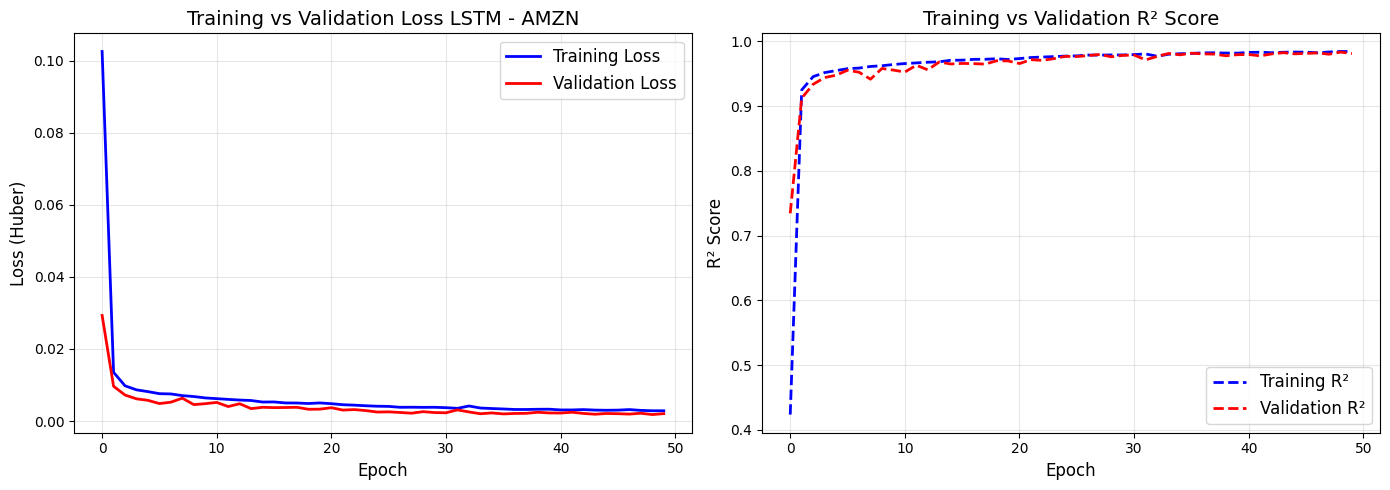

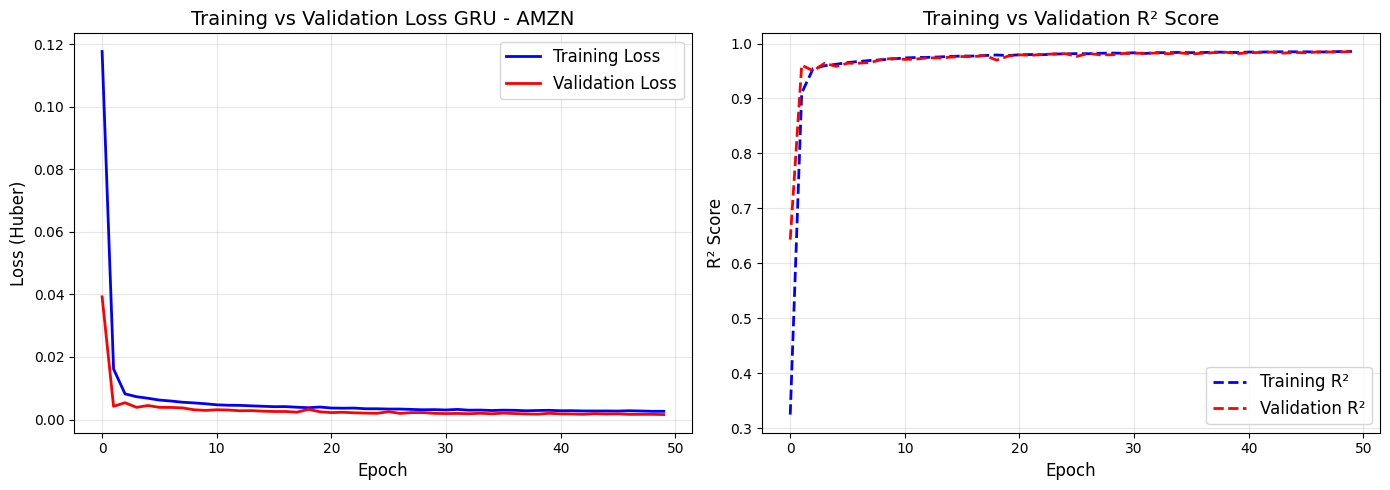

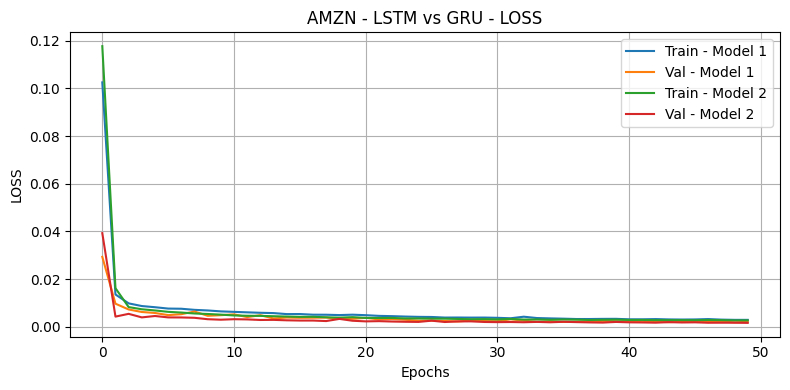

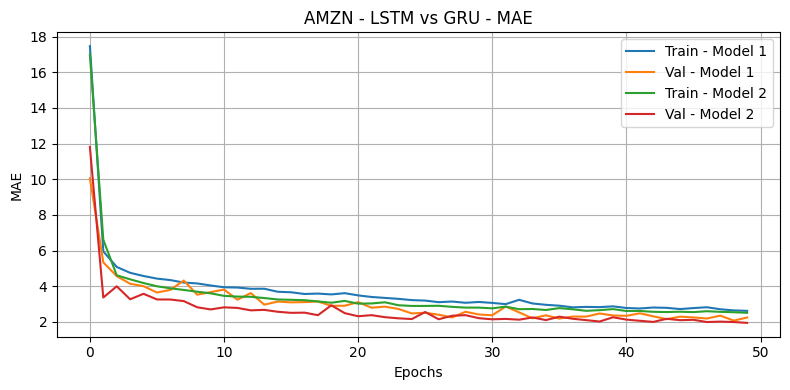

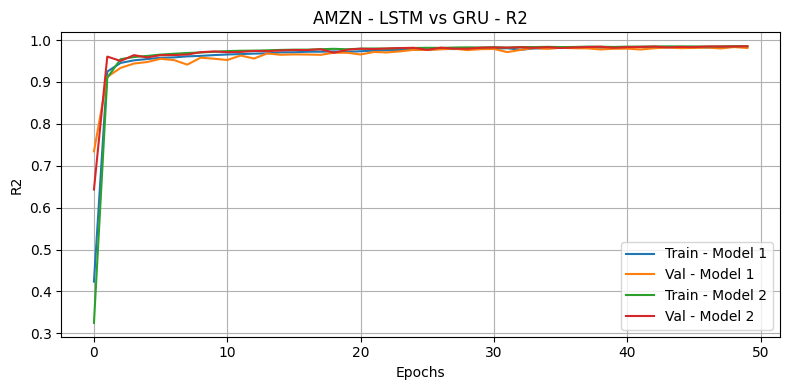

[*********************100%***********************]  1 of 1 completed


 Fetching and training models for GOOGL
Fetching data for GOOGL...
Preparing datasets for GOOGL...
Training LSTM model for GOOGL
Epoch 1/50
[Train] Loss: 0.1070 | MAE: $14.66 | R²: 0.4215
[Val]   Loss: 0.0117 | MAE: $4.44 | R²: 0.7618
New best model saved for GOOGL (R²: 0.7618)


Epoch 2/50
[Train] Loss: 0.0115 | MAE: $4.61 | R²: 0.9383
[Val]   Loss: 0.0094 | MAE: $4.06 | R²: 0.8065
New best model saved for GOOGL (R²: 0.8065)
Epoch 3/50
[Train] Loss: 0.0061 | MAE: $3.42 | R²: 0.9675
[Val]   Loss: 0.0076 | MAE: $3.67 | R²: 0.8416
New best model saved for GOOGL (R²: 0.8416)
Epoch 4/50
[Train] Loss: 0.0052 | MAE: $3.08 | R²: 0.9725
[Val]   Loss: 0.0069 | MAE: $3.51 | R²: 0.8561
New best model saved for GOOGL (R²: 0.8561)
Epoch 5/50
[Train] Loss: 0.0046 | MAE: $2.84 | R²: 0.9758
[Val]   Loss: 0.0058 | MAE: $3.19 | R²: 0.8776
New best model saved for GOOGL (R²: 0.8776)
Epoch 6/50
[Train] Loss: 0.0043 | MAE: $2.77 | R²: 0.9772
[Val]   Loss: 0.0060 | MAE: $3.32 | R²: 0.8735
Epoch 7/50
[Train] Loss: 0.0041 | MAE: $2.69 | R²: 0.9784
[Val]   Loss: 0.0058 | MAE: $3.27 | R²: 0.8776
Epoch 8/50
[Train] Loss: 0.0038 | MAE: $2.60 | R²: 0.9797
[Val]   Loss: 0.0057 | MAE: $3.12 | R²: 0.8787
New best model saved for GOOGL (R²: 0.8787)
Epoch 9/50
[Train] Loss: 0.0040 | MAE: $2.66 

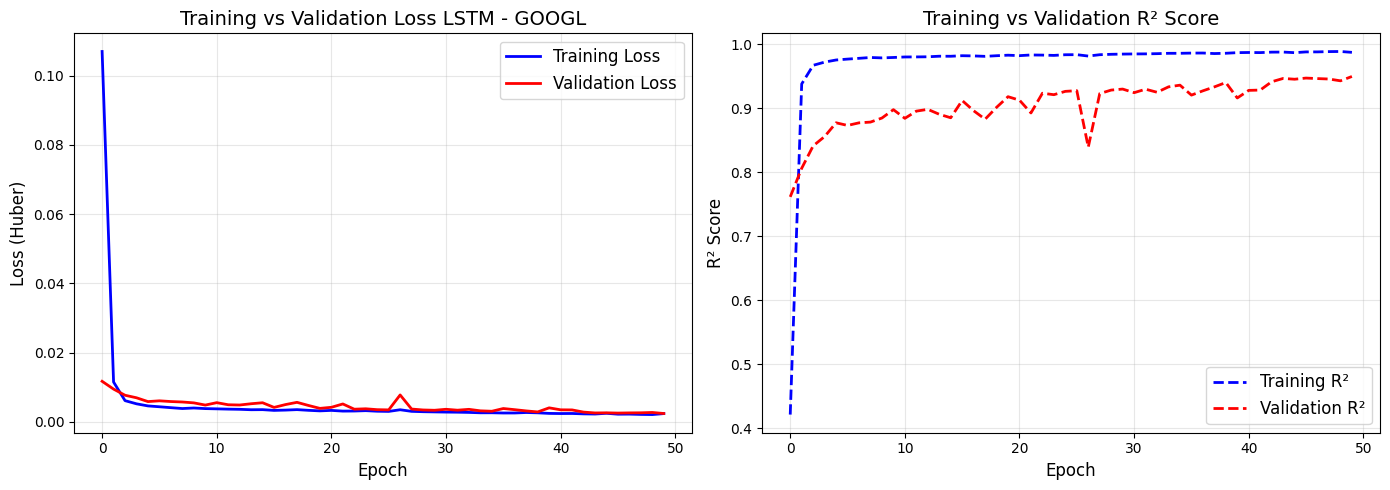

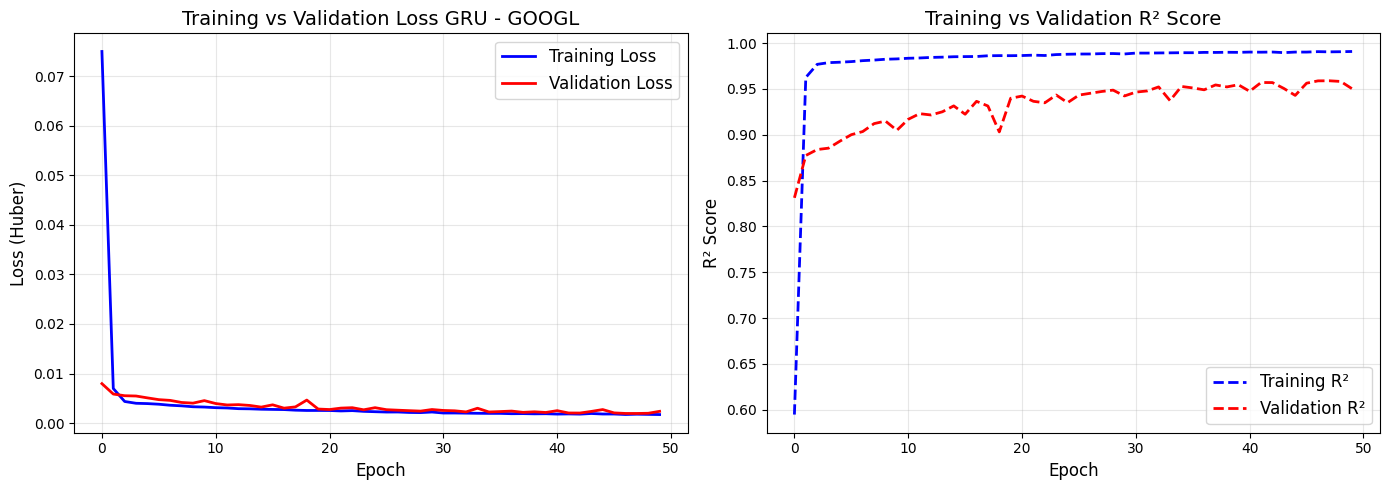

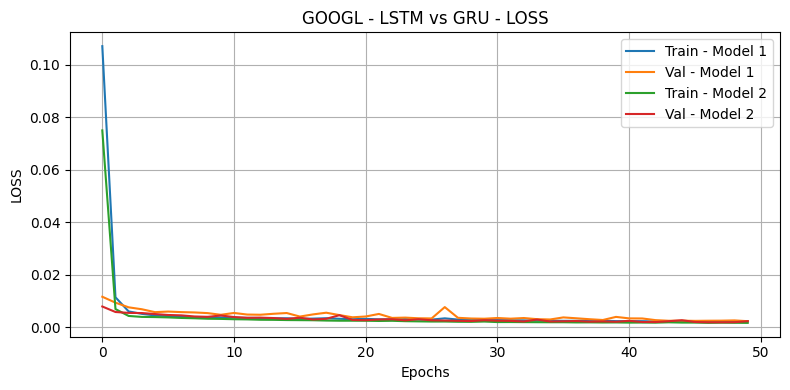

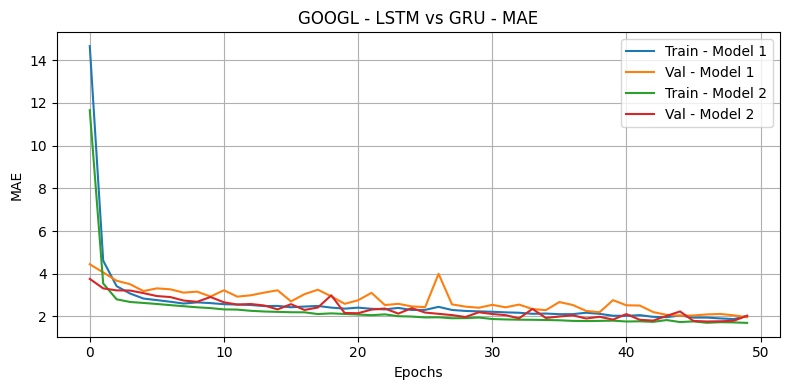

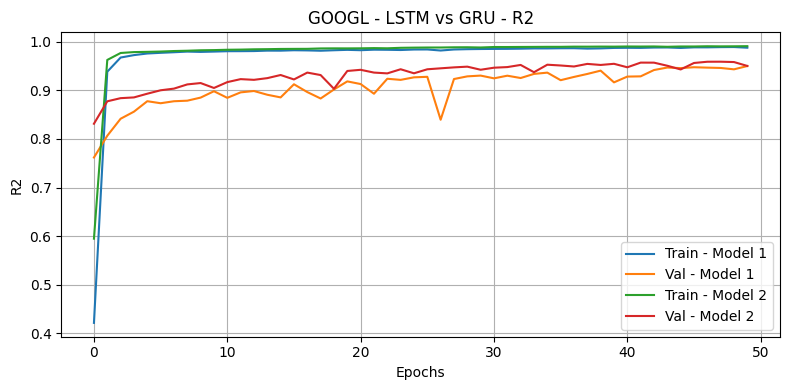

In [ ]:
import datetime
import torch
from torch.utils.data import DataLoader, TensorDataset
import os
test_x,test_y = {}, {}
# Dates
yesterday = datetime.date.today() - datetime.timedelta(days=1)
end_date = yesterday.strftime('%Y-%m-%d')
start_date = '2020-01-01'

# Params
tickers = ['TSLA', 'AAPL', 'AMZN', 'GOOGL']
seq_length = 20
batch_size = 32
epochs = 50
learning_rate = 0.001

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

input_dim = 4  # Close, SMA_10, SMA_50, RSI

for ticker in tickers:
    print(f"Fetching and training models for {ticker}")

    print(f"Fetching data for {ticker}...")
    stock_data = fetch_stock_data([ticker], start_date, end_date)
    
    print(f"Preparing datasets for {ticker}...")
    X_train, y_train, X_val, y_val, X_test, y_test, target_scaler, tickers_train, tickers_val, tickers_test = prepare_datasets(stock_data, seq_length)

    # Prepare for training and validation
    X_train_t = X_train[tickers_train == ticker]
    y_train_t = y_train[tickers_train == ticker]
    X_val_t = X_val[tickers_val == ticker]
    y_val_t = y_val[tickers_val == ticker]
    test_x[ticker] = X_test
    test_y[ticker] = y_test
    if len(X_train_t) == 0 or len(X_val_t) == 0:
        continue

    # DataLoaders for training and validation sets
    train_data = TensorDataset(torch.FloatTensor(X_train_t), torch.FloatTensor(y_train_t))
    val_data = TensorDataset(torch.FloatTensor(X_val_t), torch.FloatTensor(y_val_t))

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
    
    # LSTM and GRU models
    lstm_model = StockLSTM(input_dim).to(device)
    gru_model = StockGRU(input_dim).to(device)

    # Train LSTM model
    print(f"Training LSTM model for {ticker}")
    lstm_model, lstm_history = train_model(
        lstm_model, train_loader, val_loader, target_scaler, ticker, epochs, learning_rate
    )

    # Train GRU model
    print(f"Training GRU model for {ticker}")
    gru_model, gru_history = train_model(
        gru_model, train_loader, val_loader, target_scaler, ticker, epochs, learning_rate
    )

    # Plot training history and comparison
    plot_training_history(lstm_history, f"LSTM - {ticker}")
    plot_training_history(gru_history, f"GRU - {ticker}")
    compare_models(lstm_history, gru_history, title=f"{ticker} - LSTM vs GRU")


#now we'll analyze on test set for both models

In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
import os

model_save_base_dir = './models/'

for ticker in tickers:
    print(f"Evaluating models for {ticker}")

    X_test_t = test_x[ticker]
    y_test_t = test_y[ticker]

    if len(X_test_t) == 0:
        continue

    test_data = TensorDataset(torch.FloatTensor(X_test_t), torch.FloatTensor(y_test_t))
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

    lstm_model_path = os.path.join(model_save_base_dir, ticker, 'lstm', f'{ticker}_lstm_best.pth')
    gru_model_path = os.path.join(model_save_base_dir, ticker, 'gru', f'{ticker}_gru_best.pth')

    if not os.path.exists(lstm_model_path):
        continue

    if not os.path.exists(gru_model_path):
        continue

    # Load models
    lstm_model = StockLSTM(input_dim).to(device)
    gru_model = StockGRU(input_dim).to(device)

    lstm_model.load_state_dict(torch.load(lstm_model_path))
    gru_model.load_state_dict(torch.load(gru_model_path))

    # Evaluate LSTM on the test set
    print(f"Evaluating LSTM Model for {ticker} on Test Set")
    lstm_model.eval()
    lstm_predictions = []
    lstm_actuals = []

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            predictions = lstm_model(inputs)
            lstm_predictions.append(predictions.cpu().numpy())
            lstm_actuals.append(targets.cpu().numpy())

    lstm_predictions = np.concatenate(lstm_predictions, axis=0)
    lstm_actuals = np.concatenate(lstm_actuals, axis=0)
    lstm_predictions = lstm_predictions.reshape(-1, 1)
    lstm_actuals = lstm_actuals.reshape(-1, 1)

    lstm_predictions = target_scaler.inverse_transform(lstm_predictions)
    lstm_actuals = target_scaler.inverse_transform(lstm_actuals)

    # Calculate RMSE for LSTM
    lstm_rmse = np.sqrt(np.mean((lstm_predictions - lstm_actuals) ** 2))
    print(f"LSTM Test RMSE for {ticker} : {lstm_rmse}")

    # Evaluate GRU on the test set
    print(f"Evaluating GRU Model for {ticker} on Test Set")
    gru_model.eval()
    gru_predictions = []
    gru_actuals = []

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            predictions = gru_model(inputs)
            gru_predictions.append(predictions.cpu().numpy())
            gru_actuals.append(targets.cpu().numpy())

    gru_predictions = np.concatenate(gru_predictions, axis=0)
    gru_actuals = np.concatenate(gru_actuals, axis=0)
    gru_predictions = gru_predictions.reshape(-1, 1)
    gru_actuals = gru_actuals.reshape(-1, 1)

    gru_predictions = target_scaler.inverse_transform(gru_predictions)
    gru_actuals = target_scaler.inverse_transform(gru_actuals)

    # Calculate RMSE for GRU
    gru_rmse = np.sqrt(np.mean((gru_predictions - gru_actuals) ** 2))
    print(f"GRU Test RMSE for {ticker} : {gru_rmse}")



 Evaluating models for TSLA
Evaluating LSTM Model for TSLA on Test Set
LSTM Test RMSE for TSLA : 5.15700101852417
Evaluating GRU Model for TSLA on Test Set
GRU Test RMSE for TSLA : 4.841095447540283

 Evaluating models for AAPL
Evaluating LSTM Model for AAPL on Test Set
LSTM Test RMSE for AAPL : 19.96479606628418
Evaluating GRU Model for AAPL on Test Set
GRU Test RMSE for AAPL : 11.251243591308594

 Evaluating models for AMZN
Evaluating LSTM Model for AMZN on Test Set
LSTM Test RMSE for AMZN : 5.860480785369873
Evaluating GRU Model for AMZN on Test Set
GRU Test RMSE for AMZN : 3.8690428733825684

 Evaluating models for GOOGL
Evaluating LSTM Model for GOOGL on Test Set
LSTM Test RMSE for GOOGL : 5.199355602264404
Evaluating GRU Model for GOOGL on Test Set
GRU Test RMSE for GOOGL : 4.689777851104736


/var/folders/86/8vvffjgn0cd06ycmnfgkwtw00000gn/T/ipykernel_85478/3994106667.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  lstm_model.load_state_dict(torch.load(lstm_m

Comparing LSTM and GRU Test Performance
LSTM Test RMSE : 5.199355602264404
GRU Test RMSE : 4.689777851104736


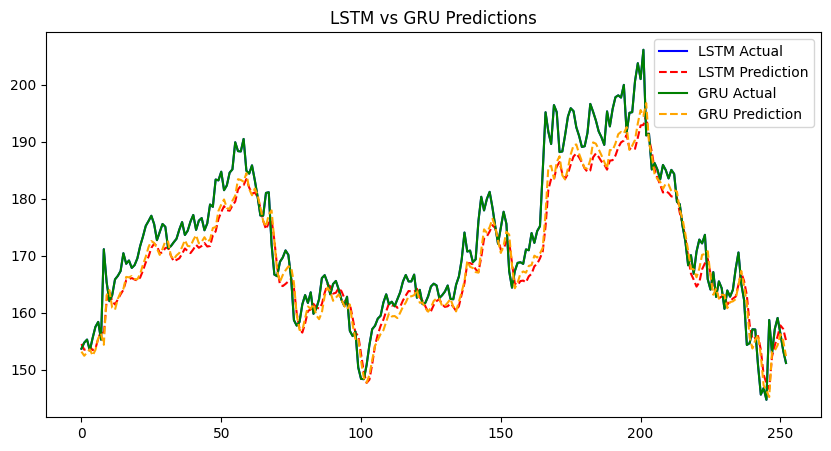

In [69]:
# comparing RMSE
def compare_models_on_test(lstm_preds, gru_preds, lstm_actuals, gru_actuals):
    lstm_rmse = np.sqrt(np.mean((lstm_preds - lstm_actuals) ** 2))
    gru_rmse = np.sqrt(np.mean((gru_preds - gru_actuals) ** 2))

    print(f"LSTM Test RMSE : {lstm_rmse}")
    print(f"GRU Test RMSE : {gru_rmse}")

    plt.figure(figsize=(10, 5))
    plt.plot(lstm_actuals, label="LSTM Actual", color="blue")
    plt.plot(lstm_preds, label="LSTM Prediction", color="red", linestyle='dashed')
    plt.plot(gru_actuals, label="GRU Actual", color="green")
    plt.plot(gru_preds, label="GRU Prediction", color="orange", linestyle='dashed')
    plt.legend()
    plt.title("LSTM vs GRU Predictions")
    plt.show()

print("Comparing LSTM and GRU Test Performance")
compare_models_on_test(lstm_predictions, gru_predictions, lstm_actuals, gru_actuals)